In [1]:
import pandas as pd 
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
import plot_of_experiment_data 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", message="findfont: Font family 'Arial' not found.")

In [2]:
##### data load #####
## dose dependent PER 
# fig1a. 
movable_s_df = pd.read_excel('data/leg_fixed_suc_labial.xlsx',index_col=False,sheet_name='movable')
movable_sg_df = pd.read_excel('data/leg_fixed_suc+geo_labial.xlsx',index_col=False,sheet_name='movable')

immov_s_df = pd.read_excel('data/leg_fixed_suc_labial.xlsx',index_col=False,sheet_name='immobilized')
immov_sg_df = pd.read_excel('data/leg_fixed_suc+geo_labial.xlsx',index_col=False,sheet_name='immobilized')


fig_params = {
'cmap' : ['#13739E', '#952B7E', '#E68613', '#4CAF50'],
'fontsize':10,
'lw' : 1,
'elw' : .75,
'ms' : 0,
'cs':1,
'lp' : 2,
'ct' : .5,
'ecolor' : 'black'}


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

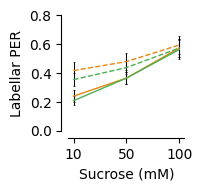

In [8]:
# fig1a: sucrose on leg 
from matplotlib.lines import Line2D


fig,ax = plt.subplots(1,1,figsize=(1.5,1.5))
plot_of_experiment_data.plot_dose_dp_PER(ax,movable_s_df,cidx=2,**fig_params)
plot_of_experiment_data.plot_dose_dp_PER(ax,movable_sg_df,cidx=3,**fig_params)
# plot_of_experiment_data.plot_statistics_result(ax,[movable_s_df,movable_sg_df])

plot_of_experiment_data.plot_dose_dp_PER(ax,immov_s_df,cidx=2,linestyle='dashed',**fig_params)
plot_of_experiment_data.plot_dose_dp_PER(ax,immov_sg_df,cidx=3,linestyle='dashed',**fig_params)
# plot_of_experiment_data.plot_statistics_result(ax,[movable_s_df,movable_sg_df])


ax.set_ylabel('Labellar PER',fontsize=10)
ax.set_xlabel('Sucrose (mM)',fontsize=10)
ax.set_ylim([0,0.8])
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))
ax.set_xticks(list(range(len(movable_s_df.columns))),[x for x in movable_s_df.columns],fontsize=10)

# legend_elements = [
#     Line2D([0], [0], color=cmap[0], lw=2, label='Suc (movable)'),
#     Line2D([0], [0], color=cmap[1], lw=2, label='Suc + Geo (movable)'),
#     Line2D([0], [0], color=cmap[2], lw=2, label='Suc (fixed)'),
#     Line2D([0], [0], color=cmap[3], lw=2, label='Suc + Geo (fixed)')
# ]

# ax.legend(
#     handles=legend_elements,
#     fontsize=8,
#     frameon=False,
#     loc='upper left',
#     ncols=4,
#     handlelength=1.0
    
# )

# plt.savefig('figures/labial_dose_dp_compare_fixed.svg',bbox_inches='tight')

In [4]:
# Valid Statistical test
import pandas as pd
from scipy.stats import mannwhitneyu

results = []

for g in movable_s_df.columns:
    stat, p = mannwhitneyu(
        movable_s_df[g],
        movable_sg_df[g],
        alternative="two-sided",
        method="auto"
    )

    results.append({
        "group": 'movable vs. immobilized ' +str(g),
        "U": stat,
        "p_raw": p
    })

results = pd.DataFrame(results)

results

,group,U,p_raw
0,movable vs. immobilized 10,9.0,0.877782
1,movable vs. immobilized 50,8.5,1.000000
2,movable vs. immobilized 100,8.5,1.000000


In [7]:
# Valid Statistical test
import pandas as pd
from scipy.stats import mannwhitneyu

results = []

for g in immov_s_df.columns:
    stat, p = mannwhitneyu(
        immov_s_df[g],
        immov_sg_df[g],
        alternative="two-sided",
        method="auto"
    )

    results.append({
        "group": 'movable vs. immobilized ' +str(g),
        "U": stat,
        "p_raw": p
    })

results = pd.DataFrame(results)

results


plot_of_experiment_data.plot_statistics_result(ax,[immov_s_df,immov_sg_df],alternative='two-sided')

[(0.0, 0.25), (1.0, 0.5), (2.0, 0.75)]

In [28]:
# Valid Statistical test
import pandas as pd
from scipy.stats import mannwhitneyu

results = []

for g in immov_s_df.columns:
    stat, p = mannwhitneyu(
        movable_s_df[g],
        immov_s_df[g],
        alternative="two-sided",
        method="auto"
    )

    results.append({
        "group": 'movable vs. immobilized ' +str(g),
        "U": stat,
        "p_raw": p
    })

results = pd.DataFrame(results)

results

,group,U,p_raw
0,movable vs. immobilized 10,1.5,0.079594
1,movable vs. immobilized 50,3.0,0.191267
2,movable vs. immobilized 100,7.5,1.000000


In [22]:
movable_s_df.columns

Index([10, 100, 500], dtype='int64')

In [15]:
movable_s_df.columns

Index([10, 100, 500], dtype='int64')

In [32]:
movable_s_df

,10,50,100
0,0.166667,0.333333,0.625000
1,0.208333,0.291667,0.375000
2,0.208333,0.333333,0.583333
3,0.375000,0.500000,0.708333
